In [1]:
# --> Append src path
import sys
from pathlib import Path
SRC = str(Path.cwd().parent / 'src')
if SRC not in sys.path:
    sys.path.insert(0, SRC)



# --> Import packages
from tqdm import tqdm
import numpy as np
import torch

import matplotlib.pyplot as plt
from IPython.display import display

from dm_control import suite
from macrocircuits import ensure_tonic, test_dm_control
ensure_tonic()

from macrocircuits.training import (  # See src/macrocircuits/training.py.
    is_trained,
    play_model,
    resolve_runs,
    run_config,
    run_path,
    train,
)

from macrocircuits.es import (
    es_config,
    is_es_trained,
    play_es_model,
    run_es,
)
from macrocircuits.plotting import (  # See src/macrocircuits/plotting.py.
    plot_performance,
    plot_performance_ma
)

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/glfw/__init__.py:917: GLFWError: (65550) b'X11: The DISPLAY environment variable is missing'
  warnings.warn(message, GLFWError)
Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


# controllers_comparison.py

In [2]:
# --> Define TASK and experiment parameters
TASK = 'foraging'
STEPS = int(2E6)

# --> Define RUNS configuration
print(f"Defining runs for {TASK.upper()} task")
LABELS_CONTROLLERS = {
    'ncap_ppo (mlp_reflex controller)': 'mlp_reflex_foraging',
    'ncap_ppo (mlp_piourette controller)': 'mlp_piourette_foraging',
    'ncap_ppo (learned_steering controller)': 'learned_steering',
    'ncap_ppo (learned_steering minus warm_start controller)': 'learned_steering_no_warm_start',
    'ncap_ppo (mlp_reflex+piourette controller)': 'mlp_reflex_piourette_foraging',
    'ncap_ppo (mlp controller)': 'mlp_foraging'
}
RUNS = [ dict(network='ncap', task=TASK, controller=v, steps=STEPS, action_noise=0.3, label=k) for k, v in LABELS_CONTROLLERS.items()]

Defining runs for FORAGING task


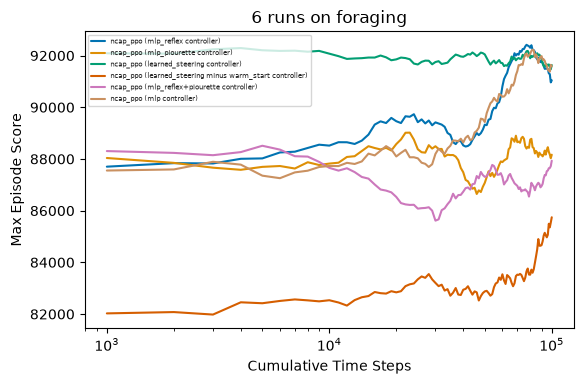

In [3]:
# rerun this cell if it displays more than the graphs
%matplotlib inline

# One panel per environment: the tasks reward different things (forward speed, food
# eaten, obstacles dodged), so their curves do not belong on shared axes.
tasks = list(dict.fromkeys(run['task'] for run in RUNS))
fig, axes = plt.subplots(1, len(tasks), figsize=(6 * len(tasks), 4), squeeze=False)

# Learning curve of every run trained above, from the same RUNS list, so the paths
# always match what the training cell wrote. plot_performance names each curve after
# the last folder of its path -- i.e. the run's label.
for ax, task in zip(axes[0], tasks):
    task_runs = [run for run in RUNS if run['task'] == task]
    # The legend names every curve, so only spell the runs out in the title while they
    # still fit on one line.
    if len(task_runs) <= 3:
        title = ' v/s '.join(run['label'].upper() for run in task_runs)
    else:
        title = f'{len(task_runs)} runs on {task}'
    plot_performance_ma([run_path(**run) for run in task_runs], ax=ax, title=title, window=25)

plt.tight_layout()
plt.show()